# Hello Soft Clustering (GMM)

### T1. Using 3 mixtures, initialize your Gaussian with means (3,3), (2,2), and (-3,-3), and standard Covariance, I, the identity matrix. Use equal mix- ture weights as the initial weights. Repeat three iterations of EM. Write down $w_{n,j}$ , $m_j$ , $\vec{μ_j}$, $\Sigma_j$ for each EM iteration. (You may do the calculations by hand or write code to do so)



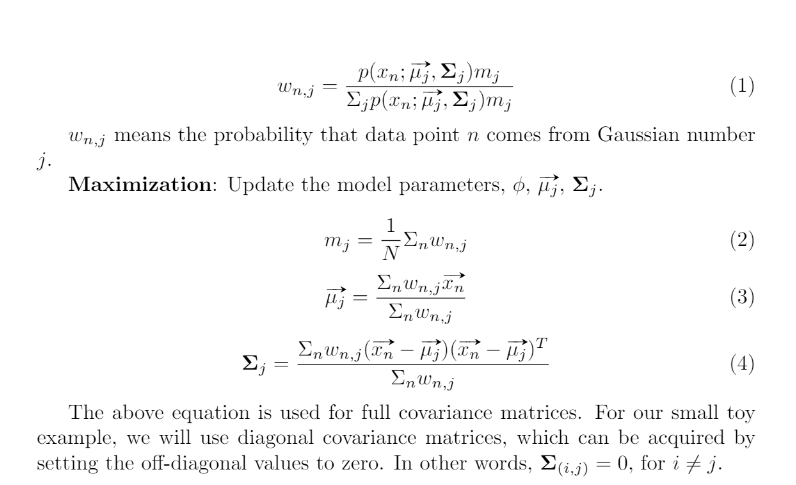

## TODO: Complete functions below including
- Fill relevant parameters in each function.
- Implement computation and return values.

These functions will be used in T1-4.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Hint: You can use this function to get gaussian distribution.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html
from scipy.stats import multivariate_normal

In [3]:
class GMM:
    def __init__(self, mixture_weight, mean_params, cov_params):
        """
        Initialize GMM.
        """
        # Copy construction values.
        self.mixture_weight = mixture_weight
        self.mean_params = mean_params
        self.cov_params = cov_params

        # Initiailize iteration.
        self.n_iter = 0

    def estimation_step(self, data):
        N = data.shape[0]
        K = len(self.mixture_weight)
        w = np.zeros((N, K))

        for j in range(K):
            rv = multivariate_normal(
                mean=self.mean_params[j],
                cov=self.cov_params[j]
            )
            w[:, j] = self.mixture_weight[j] * rv.pdf(data)

        # normalize
        w = w / np.sum(w, axis=1, keepdims=True)
        return w


    def maximization_step(self, data, w):
        N, D = data.shape
        K = w.shape[1]

        for j in range(K):
            wj = w[:, j]
            Nj = np.sum(wj)

            # update mixture weight
            self.mixture_weight[j] = Nj / N

            # update mean
            self.mean_params[j] = np.sum(wj[:, None] * data, axis=0) / Nj

            # update covariance (diagonal)
            diff = data - self.mean_params[j]
            cov = np.sum(
                wj[:, None, None] * np.matmul(diff[:, :, None], diff[:, None, :]),
                axis=0
            ) / Nj

            # keep only diagonal
            self.cov_params[j] = np.diag(np.diag(cov))


    def get_log_likelihood(self, data):
        N = data.shape[0]
        K = len(self.mixture_weight)
        log_prob = 0

        for n in range(N):
            prob = 0
            for j in range(K):
                rv = multivariate_normal(
                    mean=self.mean_params[j],
                    cov=self.cov_params[j]
                )
                prob += self.mixture_weight[j] * rv.pdf(data[n])
            log_prob += np.log(prob)

        return log_prob

    def print_iteration(self):
        print("m :\n", self.mixture_weight)
        print("mu :\n", self.mean_params)
        print("covariance matrix :\n", self.cov_params)
        print("-------------------------------------------------------------")

    def perform_em_iterations(self, data, num_iterations, display=True):
        """
        Perform estimation & maximization steps with num_iterations.
        Then, return list of log_likelihood from those iterations.
        """
        log_prob_list = []

        # Display initialization.
        if display:
            print("Initialization")
            self.print_iteration()

        for n_iter in range(num_iterations):
            w = self.estimation_step(data)
            self.maximization_step(data, w)

            log_prob = self.get_log_likelihood(data)
            log_prob_list.append(log_prob)

            if display:
                print(f"Iteration: {n_iter + 1}")
                self.print_iteration()

        return log_prob_list

In [4]:
num_iterations = 3
num_mixture = 3
mixture_weight = [1] * num_mixture # m
mean_params = np.array([[3,3], [2,2], [-3,-3]], dtype = float)
cov_params = np.array([np.eye(2)] * num_mixture)

X, Y = np.array([1, 3, 2, 8, 6, 7, -3, -2, -7]), np.array([2, 3, 2, 8, 6, 7, -3, -4, -7])
data = np.vstack([X,Y]).T

gmm = GMM(mixture_weight, mean_params, cov_params)
log_prob_list = gmm.perform_em_iterations(data, num_iterations)

Initialization
m :
 [1, 1, 1]
mu :
 [[ 3.  3.]
 [ 2.  2.]
 [-3. -3.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------
Iteration: 1
m :
 [0.45757241940119386, 0.20909424706571345, 0.33333333353309275]
mu :
 [[ 5.78992692  5.81887265]
 [ 1.67718211  2.14523106]
 [-4.         -4.66666666]]
covariance matrix :
 [[[4.53619412 0.        ]
  [0.         4.28700611]]

 [[0.51645579 0.        ]
  [0.         0.13152618]]

 [[4.66666668 0.        ]
  [0.         2.88888891]]]
-------------------------------------------------------------
Iteration: 2
m :
 [0.40711618315944753, 0.25954960846072456, 0.3333342083798279]
mu :
 [[ 6.27176215  6.27262711]
 [ 1.72091544  2.14764812]
 [-3.99998589 -4.6666488 ]]
covariance matrix :
 [[[2.94672736 0.        ]
  [0.         2.93847196]]

 [[0.49649261 0.        ]
  [0.         0.12584815]]

 [[4.66673088 0.        ]
  [0.         2.88900236]]]
--------------

### T2. Plot the log likelihood of the model given the data after each EM step. In other words, plot $\log \prod_n p( \vec{x_n} |φ, \vec{μ} , Σ)$. Does it goes up every iteration just as we learned in class?



In [5]:
log_prob_list

[-39.72599315621763, -38.80573198057705, -36.51297631141434]

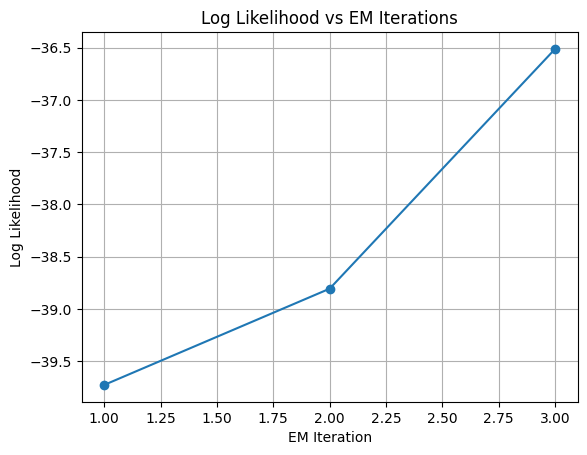

In [6]:
iterations = [1, 2, 3]

plt.plot(iterations, log_prob_list, marker='o')
plt.xlabel("EM Iteration")
plt.ylabel("Log Likelihood")
plt.title("Log Likelihood vs EM Iterations")
plt.grid(True)
plt.show()

    ANS : ผลลัพธ์เป็นไปตามในชั้นเรียน เพราะ ค่า log-likelihood เพิ่มขึ้นในทุก iteration ซึ่งสอดคล้องกับทฤษฎีของ EM algorithm ที่รับประกันว่า log-likelihood จะไม่ลดลงในแต่ละรอบของการเทรน

### T3. Using 2 mixtures, initialize your Gaussian with means (3,3) and (-3,-3), and standard Covariance, I, the identity matrix. Use equal mixture weights as the initial weights. Repeat three iterations of EM. Write down $w_{n,j}$ , $m_j$ , $\vec{μ_j}$, $\Sigma_j$ for each EM iteration.



In [7]:
num_mixture = 2
mixture_weight = [1] * num_mixture

mean_params = np.array([[3,3], [-3,-3]], dtype=float)
cov_params = np.array([np.eye(2)] * num_mixture)

gmm2 = GMM(mixture_weight, mean_params, cov_params)
log_prob_list2 = gmm2.perform_em_iterations(data, num_iterations=3)

Initialization
m :
 [1, 1]
mu :
 [[ 3.  3.]
 [-3. -3.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------
Iteration: 1
m :
 [0.6666666649702522, 0.3333333350297478]
mu :
 [[ 4.50000001  4.66666667]
 [-3.99999997 -4.66666663]]
covariance matrix :
 [[[6.91666665 0.        ]
  [0.         5.88888889]]

 [[4.66666677 0.        ]
  [0.         2.8888891 ]]]
-------------------------------------------------------------
Iteration: 2
m :
 [0.6666943621060054, 0.3333056378939946]
mu :
 [[ 4.49961311  4.66620178]
 [-3.99993241 -4.66651231]]
covariance matrix :
 [[[6.91944755 0.        ]
  [0.         5.89275124]]

 [[4.66806942 0.        ]
  [0.         2.89103318]]]
-------------------------------------------------------------
Iteration: 3
m :
 [0.6666945259520648, 0.3333054740479351]
mu :
 [[ 4.49961084  4.66619903]
 [-3.99993206 -4.66651141]]
covariance matrix :
 [[[6.91946372 0.        ]
  [0.         5.8927741 ]]



### T4. Plot the log likelihood of the model given the data after each EM step. Compare the log likelihood between using two mixtures and three mixtures. Which one has the better likelihood?

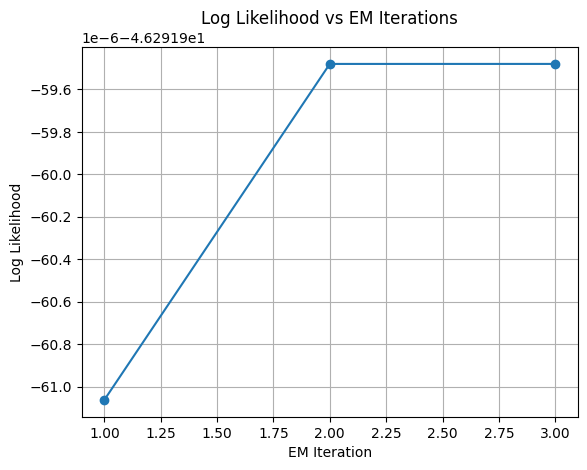

In [8]:
iterations = [1, 2, 3]

plt.plot(iterations, log_prob_list2, marker='o')
plt.xlabel("EM Iteration")
plt.ylabel("Log Likelihood")
plt.title("Log Likelihood vs EM Iterations")
plt.grid(True)
plt.show()

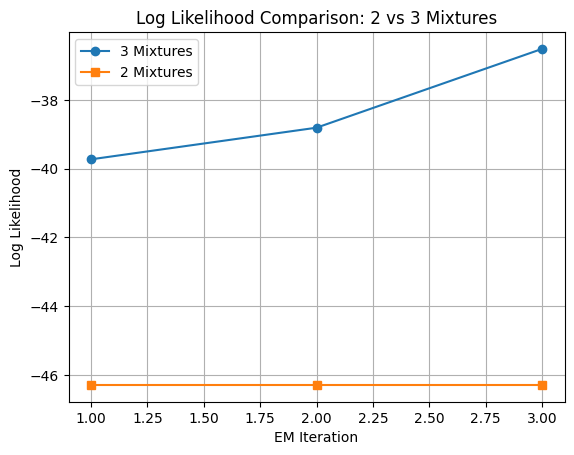

In [9]:
iterations = [1, 2, 3]

plt.plot(iterations, log_prob_list, marker='o', label='3 Mixtures')
plt.plot(iterations, log_prob_list2, marker='s', label='2 Mixtures')

plt.xlabel("EM Iteration")
plt.ylabel("Log Likelihood")
plt.title("Log Likelihood Comparison: 2 vs 3 Mixtures")
plt.legend()
plt.grid(True)
plt.show()


    ANS : 3 mixtures ให้ค่า log-likelihood สูงกว่าโมเดลที่ใช้ 2 mixtures เนื่องจากมีความยืดหยุ่นมากกว่าและสามารถอธิบายโครงสร้างของข้อมูลได้ละเอียดกว่า 3 mixtures เลยดีกว่าแบบ 2 mixtures

### OT1. Using 2 mixtures, initialize your Gaussian with means (0,0) and (10000,10000). Explain what happens. From this case, explain how a proper initialization should be performed. What other tricks can be used to prevent this from happening?

In [10]:
num_mixture = 2
mixture_weight = [1] * num_mixture

mean_params = np.array([[0,0], [10000,10000]], dtype=float)
cov_params = np.array([np.eye(2)] * num_mixture)

gmm3 = GMM(mixture_weight, mean_params, cov_params)
log_prob_list3 = gmm3.perform_em_iterations(data, num_iterations=3)

Initialization
m :
 [1, 1]
mu :
 [[    0.     0.]
 [10000. 10000.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------


/tmp/ipykernel_7822/2683677521.py:43: RuntimeWarning: invalid value encountered in divide
  self.mean_params[j] = np.sum(wj[:, None] * data, axis=0) / Nj


ValueError: array must not contain infs or NaNs

    ANS : Gaussian ที่ถูกตั้งค่าเริ่มต้นไว้ที่ (10000,10000) อยู่ไกลจากข้อมูลมาก ส่งผลให้ mixture weight ลดลงจนเป็นศูนย์ และทำให้การอัปเดตพารามิเตอร์เกิดค่า NaN จนเกิด error ตามใน code ทำให้เห็นว่า EM algorithm มีความไวต่อการตั้งค่าเริ่มต้น การตั้งค่าเริ่มต้นที่เหมาะสมควรใช้ค่า mean ที่อยู่ใกล้กับข้อมูล


# The face database

In [ ]:
# Download facedata for google colab
# !wget -nc https://github.com/ekapolc/Pattern_2024/raw/main/HW/HW03/facedata_mat.zip
# !unzip facedata_mat.zip

Archive:  facedata_mat.zip
  inflating: facedata.mat            


In [11]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import img_as_float

# Change path to your facedata.mat file.
facedata_path = 'facedata.mat'

data = scipy.io.loadmat(facedata_path)
data_size = data['facedata'].shape

%matplotlib inline
data_size

(40, 10)

### Preprocess xf

In [12]:
xf = np.zeros((data_size[0], data_size[1], data['facedata'][0,0].shape[0], data['facedata'][0,0].shape[1]))
for i in range(data['facedata'].shape[0]):
    for j in range(data['facedata'].shape[1]):
        xf[i,j] = img_as_float(data['facedata'][i,j])

In [13]:
xf.shape

(40, 10, 56, 46)

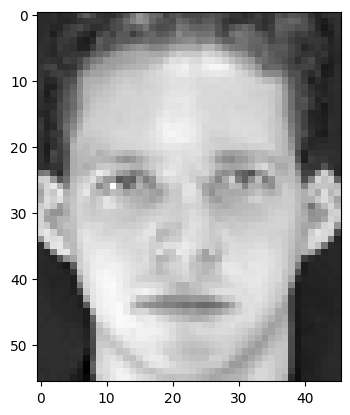

In [14]:
# Example: Ploting face image.
plt.imshow(xf[0,0], cmap = 'gray')
plt.show()

### T5. What is the Euclidean distance between xf[0,0] and xf[0,1]? What is the Euclidean distance between xf[0,0] and xf[1,0]? Does the numbers make sense? Do you think these numbers will be useful for face verification?

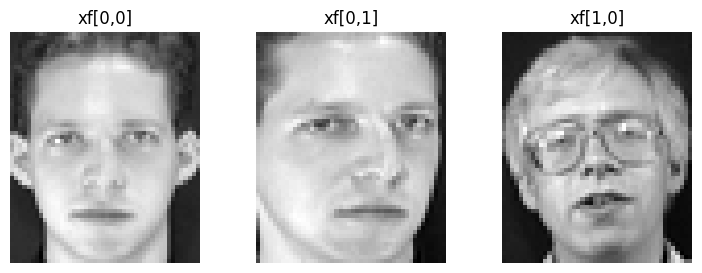

In [15]:
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(xf[0,0], cmap='gray')
plt.title('xf[0,0]')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(xf[0,1], cmap='gray')
plt.title('xf[0,1]')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(xf[1,0], cmap='gray')
plt.title('xf[1,0]')
plt.axis('off')

plt.show()


In [16]:
def L2_dist(x1, x2):
    x1 = x1.reshape(-1)
    x2 = x2.reshape(-1)
    return np.sqrt(np.sum((x1 - x2) ** 2))

# Test L2_dist
def test_L2_dist():
    assert L2_dist(np.array([1, 2, 3]), np.array([1, 2, 3])) == 0.0
    assert  L2_dist(np.array([0, 0, 0]), np.array([1, 2, 3])) == np.sqrt(14)

test_L2_dist()

print('Euclidean distance between xf[0,0] and xf[0,1] is', L2_dist(xf[0,0], xf[0,1]))
print('Euclidean distance between xf[0,0] and xf[1,0] is', L2_dist(xf[0,0], xf[1,0]))

Euclidean distance between xf[0,0] and xf[0,1] is 10.037616294165492
Euclidean distance between xf[0,0] and xf[1,0] is 8.173295099737281


    ANS : ไม่ make sense เพราะผลลัพธ์ที่ได้คือ 
    Euclidean distance between xf[0,0] and xf[0,1] is 10.037616294165492
    Euclidean distance between xf[0,0] and xf[1,0] is 8.173295099737281

    จะเห็นว่า xf[0,0] และ xf[0,1] เป็นคนเดียวกันควรจะมี Euclidean distance น้อยกว่า xf[0,0] และ xf[1,0] แต่เพราะมีความแตกต่างของ pose และแสง ทำให้ค่า Euclidean distance สูงกว่าภาพ xf[0,0] และ xf[1,0] ซึ่งเป็นคนละคนแต่มี pose ใกล้เคียงกัน
    ผลลัพธ์นี้แสดงให้เห็นว่า Euclidean distance บนค่า pixel ดิบมีความไวต่อ pose และ illumination มาก จึงไม่เหมาะสำหรับการทำ face verification โดยตรง 
    แต่ Euclidean distance มีประโยชน์ต่อ face verification ถ้าเราทำอย่างถูกวิธีโดยการใช้การสกัด feature เช่น PCA หรือ Fisherface เพื่อให้ระยะทางสะท้อนความเหมือนของตัวบุคคลได้ดียิ่งขึ้น

### T6. Write a function that takes in a set of feature vectors T and a set of feature vectors D, and then output the similarity matrix A. Show the matrix as an image. Use the feature vectors from the first 3 images from all 40 people for list T (in order x[0, 0], x[0, 1], x[0, 2], x[1, 0], x[1, 1], ...x[39, 2]). Use the feature vectors from the remaining 7 images from all 40 people for list D (in order x[0, 3], x[0, 4], x[0, 5], x[1, 6], x[0, 7], x[0, 8], x[0, 9], x[1, 3], x[1, 4]...x[39, 9]). We will treat T as our training images and D as our testing images

In [17]:
def organize_shape(matrix):
    people, images, H, W = matrix.shape
    res = matrix.reshape(people * images, H * W)

    return res

def generate_similarity_matrix(A, B):
    num_A = A.shape[0]
    num_B = B.shape[0]
    similarity_matrix = np.zeros((num_A, num_B))

    for i in range(num_A):
        for j in range(num_B):
            similarity_matrix[i, j] = L2_dist(A[i], B[j])

    return similarity_matrix

def test_generate_similarity_matrix():
    test_A = np.array([[1, 2],[3,4]])
    test_B = np.array([[1, 2], [5, 6], [7, 8]])
    expected_matrix = np.sqrt(np.array([[0, 32, 72], [8, 8, 32]]))
    assert (generate_similarity_matrix(test_A, test_B) == expected_matrix).all()

test_generate_similarity_matrix()

In [18]:
from skimage import img_as_float

T = []
for i in range(40):
    for j in range(3):
        T.append(img_as_float(xf[i, j]))
T = np.array(T)  

D = []
for i in range(40):
    for j in range(3, 10):
        D.append(img_as_float(xf[i, j]))
D = np.array(D)   

T_vec = T.reshape(T.shape[0], -1)
D_vec = D.reshape(D.shape[0], -1)

similarity_matrix = generate_similarity_matrix(T_vec, D_vec)

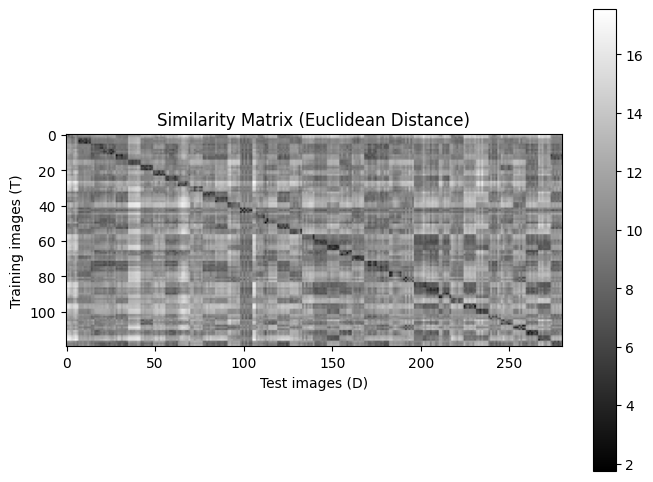

In [19]:
plt.figure(figsize=(8,6))
plt.imshow(similarity_matrix, cmap='gray')
plt.colorbar()
plt.title("Similarity Matrix (Euclidean Distance)")
plt.xlabel("Test images (D)")
plt.ylabel("Training images (T)")
plt.show()

### T7. From the example similarity matrix above, what does the black square between [5:10,5:10] suggest about the pictures from person number 2? What do the patterns from person number 1 say about the images from person 1?


In [20]:
from skimage import img_as_float

x = data['facedata'] 
imgs = []
for i in range(5):       
    for j in range(5):     
        imgs.append(img_as_float(x[i, j]))

imgs = np.array(imgs)    
imgs_vec = imgs.reshape(imgs.shape[0], -1) 
sim_example = generate_similarity_matrix(imgs_vec, imgs_vec)

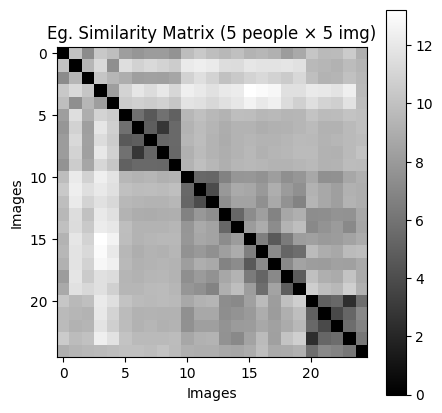

In [21]:
plt.figure(figsize=(5,5))
plt.imshow(sim_example, cmap='gray')
plt.colorbar()
plt.title("Eg. Similarity Matrix (5 people × 5 img)")
plt.xlabel("Images")
plt.ylabel("Images")
plt.show()

        ANS : จากบริเวณ [5:10], [5:10] มีสีเข้ม หมายความว่ามี Euclidean distance ที่ต่ำ นั่นคือภาพใน dataframe ของคนนี้มีความคล้ายๆกัน มีการเปลี่ยนแปลง pose กับ illumination น้อย
        ส่วน block ของ person number 1 มีสีไม่สม่ำเสมอและสว่างกว่าบางส่วน แสดงว่า ภาพของ person number 1 มีความหลากหลายมากกว่า เช่น มีการเปลี่ยน pose หรือแสงมาก ทำให้แม้จะเป็นคนเดียวกัน แต่ค่า Euclidean distance ระหว่างภาพยังค่อนข้างสูง


### T8. Write a function that takes in the similarity matrix created from the previous part, and a threshold t as inputs. The outputs of the function are the true positive rate and the false alarm rate of the face verification task (280 Test images, tested on 40 people, a total of 11200 testing per threshold). What is the true positive rate and the false alarm rate for t = 10?

In [22]:
def evaluate_performance(similarity_matrix, threshold):
    num_train, num_test = similarity_matrix.shape

    true_positive = 0
    false_positive = 0

    total_positive = num_test          # 280
    total_negative = num_test * 39     # test × (คนอื่น)

    for test_idx in range(num_test):
        test_person = test_idx // 7

        # ตรวจคนเดียวกัน
        same_person_dists = similarity_matrix[
            test_person*3:(test_person+1)*3, test_idx
        ]

        if np.min(same_person_dists) <= threshold:
            true_positive += 1

        # ตรวจคนอื่น
        for other_person in range(40):
            if other_person == test_person:
                continue

            other_dists = similarity_matrix[
                other_person*3:(other_person+1)*3, test_idx
            ]

            if np.min(other_dists) <= threshold:
                false_positive += 1

    true_pos_rate = true_positive / total_positive
    false_pos_rate = false_positive / total_negative

    return true_pos_rate, false_pos_rate

# Quick check
# (true_pos_rate, false_pos_rate) should be (0.9928571428571429, 0.33507326007326005)
evaluate_performance(similarity_matrix, 9.5)

(0.9928571428571429, 0.33507326007326005)

In [23]:
true_pos_rate, false_pos_rate = evaluate_performance(similarity_matrix, 10)
print(true_pos_rate, false_pos_rate)

0.9964285714285714 0.4564102564102564


        ANS: เมื่อตั้ง threshold เป็น 10 ทำให้ได้ TP สูง (99.64%) แสดงว่าสามารถตรวจจับภาพของคนเดียวกันได้ดี แต่มีค่า FP ค่อนข้างสูง (45.64%) หมายความว่ายังมีการจับคู่ผิดกับคนอื่นจำนวนมาก บ่งบอกว่า Euclidean distance บนค่า pixel ดิบ อาจยังทำงานได้ไม่ดีพอที่จะนำไปใช้

### T9. Plot the RoC curve for this simple verification system. What should be the minimum threshold to generate the RoC curve? What should be the maximum threshold? Your RoC should be generated from at least 1000 threshold levels equally spaced between the minimum and the maximum. (You should write a function for this).

In [24]:
t_min = np.min(similarity_matrix)
t_max = np.max(similarity_matrix)
t_min, t_max

(1.7420153428787784, 17.541726165424688)

In [25]:
def calculate_roc(input_mat, num_thresholds=1000):
    t_min = np.min(input_mat)
    t_max = np.max(input_mat)
    thresholds = np.linspace(t_min, t_max, num_thresholds)

    tpr_list = []
    far_list = []

    for t in thresholds:
        tpr, far = evaluate_performance(input_mat, t)
        tpr_list.append(tpr)
        far_list.append(far)

    tpr_list = np.array(tpr_list)
    far_list = np.array(far_list)

    return tpr_list, far_list

def plot_roc(input_mat):
    tpr_list, far_list = calculate_roc(input_mat)

    plt.figure(figsize=(6,6))
    plt.plot(far_list, tpr_list)
    plt.xlabel("False Alarm Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Face Verification)")
    plt.grid(True)
    plt.show()

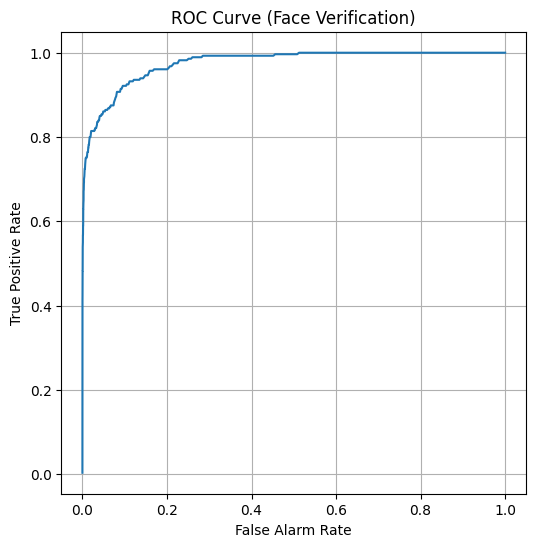

In [26]:
plot_roc(similarity_matrix)

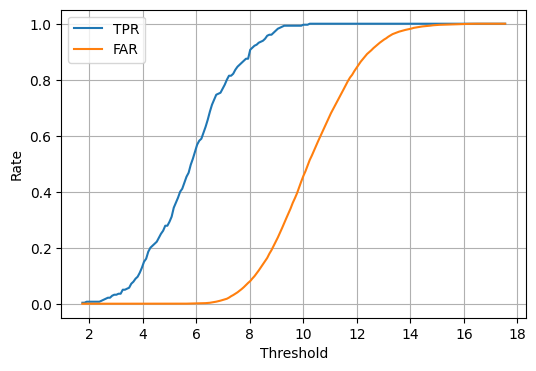

In [27]:
def plot_rates_vs_threshold(input_mat):
    tpr_list, far_list = calculate_roc(input_mat, 200)
    thresholds = np.linspace(t_min, t_max, 200)

    plt.figure(figsize=(6,4))
    plt.plot(thresholds, tpr_list, label='TPR')
    plt.plot(thresholds, far_list, label='FAR')
    plt.xlabel("Threshold")
    plt.ylabel("Rate")
    plt.legend()
    plt.grid(True)
    plt.show()
plot_rates_vs_threshold(similarity_matrix)

    ANS: จากกราฟจะเห็นว่า TP rate เพิ่มขึ้นเร็วจนเกือบถึง 1 ที่ threshold ค่อนข้างต่ำ แต่ในทางกลับกัน FP rate  ก็เพิ่มขึ้นเร็วเหมือนกัน ถึงแม้จะเริ่มเพิ่มช้ากว่า TP rate ก็ตาม แสดงว่าการได้ค่า TPR สูงมากต้องแลกกับ FAR ที่สูง ซึ่งสะท้อนถึงข้อจำกัดของการใช้ Euclidean distance บน pixel ดิบ

### T10. What is the EER (Equal Error Rate)? What is the recall rate at 0.1% false alarm rate? (Write this in the same function as the previous question)



In [ ]:
def calculate_roc_metrics(input_mat, num_thresholds=1000):
    tpr_list, far_list = calculate_roc(input_mat, num_thresholds)

    # ----- EER -----
    # Method: find point where FAR ≈ FRR
    frr_list = 1 - tpr_list
    eer_idx = np.argmin(np.abs(far_list - frr_list))
    eer_tpr = tpr_list[eer_idx]

    # ----- Recall at FAR = 0.1% -----
    target_far = 0.001
    valid_idx = np.where(far_list <= target_far)[0]
    recall_at_001 = tpr_list[valid_idx[-1]] if len(valid_idx) > 0 else 0

    return eer_tpr, recall_at_001, tpr_list, far_list

eer_tpr, recall_at_001, tpr_list, far_list = calculate_roc_metrics(similarity_matrix)
print("EER (FAR = FRR):", 1-eer_tpr)
print("TPR at EER:", eer_tpr)
print("Recall at 0.1% FAR:", recall_at_001)

# EER should be 0.09075091575091576 or 0.08864468864468865 or 0.09285714285714286
# TPR at EER should be either 0.9071428571428571 or 0.9103759398496248 depending on method.
# Recall rate at 0.1% false alarm rate should be 0.5428571428571428.

EER (FAR = FRR): 0.09285714285714286
TPR at EER: 0.9071428571428571
Recall at 0.1% FAR: 0.5428571428571428


    ANS: EER คือจุดที่ค่า false alarm rate เท่ากับ false rejection rate โดยในระบบนี้ค่า EER (error rate) ประมาณ 0.092 ซึ่งหมายความว่าระบบมีอัตราความผิดพลาดประมาณ 9.2% และมีค่า recall (true positive rate) ประมาณ 0.907
    เมื่อกำหนด false alarm rate ไว้ที่ 0.1% ระบบสามารถตรวจจับภาพของคนเดียวกันได้เพียงประมาณ 54%

### T11. Compute the mean vector from the training images. Show the vector as an image (use numpy.reshape()). This is typically called the meanface (or meanvoice for speech signals). You answer should look exactly like the image shown below.

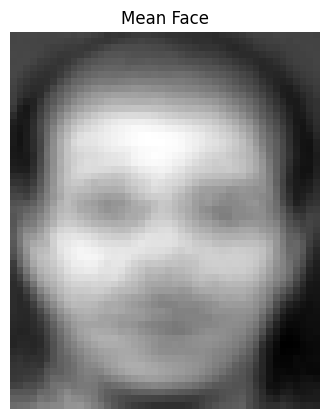

In [30]:
mean_vector = np.mean(T_vec, axis=0)
meanface = mean_vector.reshape(56, 46)

plt.figure(figsize=(4,5))
plt.imshow(meanface, cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()

### T12. What is the size of the covariance matrix? What is the rank of the covariance matrix?


In [ ]:
# TODO: Find the size and the rank of the covariance matrix.

In [31]:
N, d = T_vec.shape
print(f"covariance matrix size: {d} x {d}")
print(f"rank of covariance matrix: {min(N-1, d)}")

covariance matrix size: 2576 x 2576
rank of covariance matrix: 119


    ANS: Covariance matrix (Σ) มีขนาด d × d เนื่องจากมันคำนวณความแปรปรวนร่วม (covariance) ระหว่างแต่ละคู่ของ dimensions
    ดังนั้น ขนาดของ covariance matrix = 2576 × 2576

    Rank ของ Covariance Matrix สูงสุดที่เป็นไปได้ = min(N-1, d) = 119



### T13. What is the size of the Gram matrix? What is the rank of Gram matrix? If we compute the eigenvalues from the Gram matrix, how many non- zero eigenvalues do we expect to get?

In [32]:
# TODO: Compute gram matrix.
X_hat = (T_vec - mean_vector).T
gram_matrix = X_hat.T @ X_hat
eigvals, eigvecs = np.linalg.eigh(gram_matrix)

In [33]:
# TODO: Show size and rank of Gram matrix.
print(f"size of gram matrix: {gram_matrix.shape}")
print(f"rank of gram matrix: {np.linalg.matrix_rank(gram_matrix)}")
print(f"number of non-zero eigenvalues: {np.sum(eigvals > 1e-10)}")

size of gram matrix: (120, 120)
rank of gram matrix: 119
number of non-zero eigenvalues: 119


    ANS: size of gram matrix: (120, 120)
    rank of gram matrix: 119
    number of non-zero eigenvalues: 119

## T14. Is the Gram matrix also symmetric? Why?


In [34]:
# X_hat shape: (2576, 120)
gram_matrix = X_hat.T @ X_hat
np.allclose(gram_matrix, gram_matrix.T)

True

    ANS: Gram matrix เป็น symmetric เนื่องจากนิยามเป็น G=X-transpose * X ซึ่งเมื่อ transpose แล้วจะได้เมทริกซ์เดิม ทำให้ G=G-transpose

### T15. Compute the eigenvectors and eigenvalues of the Gram matrix, v 0 and λ. Sort the eigenvalues and eigenvectors in descending order so that the first eigenvalue is the highest, and the first eigenvector corresponds to the best direction. How many non-zero eigenvalues are there? If you see a very small value, it is just numerical error and should be treated as zero.




In [35]:
# Hint: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html

def calculate_eigenvectors_and_eigenvalues(matrix):
    # eigenvalues: (N,), eigenvectors: (N, N)
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)

    # sort eigenvalues in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return eigenvalues, eigenvectors

eigenvalues, eigenvectors = calculate_eigenvectors_and_eigenvalues(gram_matrix)

def test_eigenvalues_eigenvectors():
    # Dot product of an eigenvector pair should equal to zero.
    assert np.round(eigenvectors[10].dot(eigenvectors[20]), 10) == 0.0

    # Check if eigenvalues are sorted.
    assert list(eigenvalues) == sorted(eigenvalues, reverse = True)

test_eigenvalues_eigenvectors()

In [36]:
num_nonzero = np.sum(eigenvalues > 1e-10)
print("Number of non-zero eigenvalues:", num_nonzero)

Number of non-zero eigenvalues: 119


    ANS: มี eigenvalues ที่ไม่เป็นศูนย์จำนวน 119 ค่า ซึ่งสอดคล้องกับ rank ของ Gram matrix

### T16. Plot the eigenvalues. Observe how fast the eigenvalues decrease. In class, we learned that the eigenvalues is the size of the variance for each eigenvector direction. If I want to keep 95% of the variance in the data, how many eigenvectors should I use?

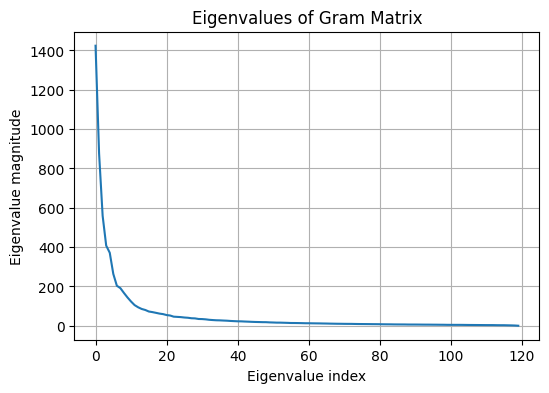

In [37]:
plt.figure(figsize=(6,4))
plt.plot(eigenvalues)
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue magnitude")
plt.title("Eigenvalues of Gram Matrix")
plt.grid(True)
plt.show()

In [38]:
cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)
num_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print("Number of eigenvectors to keep 95% variance:", num_components_95)

Number of eigenvectors to keep 95% variance: 64


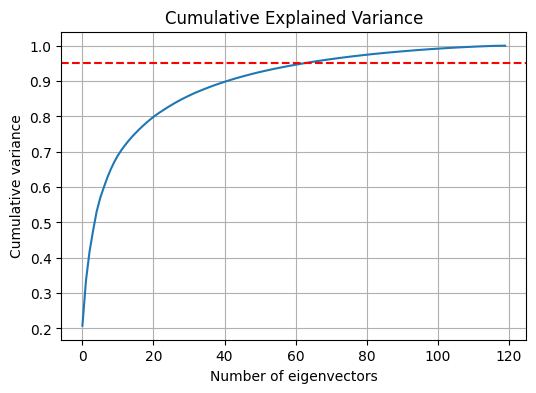

In [39]:
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance)
plt.axhline(0.95, color='r', linestyle='--')
plt.xlabel("Number of eigenvectors")
plt.ylabel("Cumulative variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

    ANS: จากกราฟจะเห็นว่า eigenvalues ลดลงอย่างรวดเร็ว แสดงว่า variance ส่วนใหญ่กระจุกอยู่ใน eigenvectors แรกๆ
    จากการคำนวณเพื่อคง variance ไว้ที่95% พบว่าต้องใช้ eigenvectors 64 ตัว

### T17. Compute $\vec{v}$ . Don’t forget to renormalize so that the norm of each vector is 1 (you can use numpy.linalg.norm). Show the first 10 eigenvectors as images. Two example eigenvectors are shown below. We call these images eigenfaces (or eigenvoice for speech signals).

In [40]:
# TODO: Compute v, then renormalize it.

# INSERT CODE HERE

v = X_hat @ eigenvectors 
# normalize each eigenvector to have norm = 1
v = v / np.linalg.norm(v, axis=0, keepdims=True)

In [41]:
def test_eignevector_cov_norm(v):
    assert (np.round(np.linalg.norm(v, axis=0), 1) == 1.0).all()

test_eignevector_cov_norm(v)

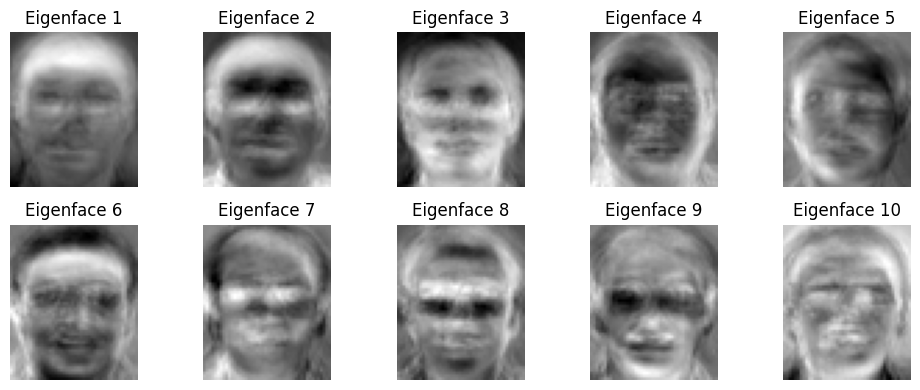

In [42]:
# TODO: Show the first 10 eigenvectors as images.

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    eigenface = v[:, i].reshape(56, 46)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### T18. From the image, what do you think the first eigenvector captures? What about the second eigenvector? Look at the original images, do you think biggest variance are capture in these two eigenvectors?

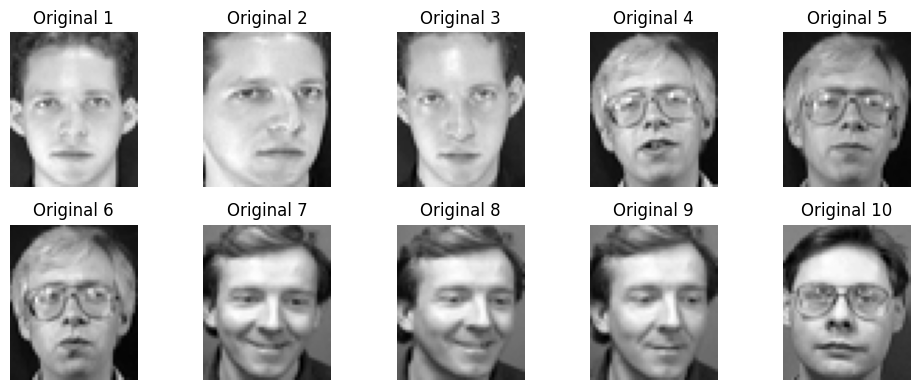

In [43]:
plt.figure(figsize=(10, 4))

for i in range(10):  
    plt.subplot(2, 5, i + 1)
    plt.imshow(T_vec[i,:].reshape(56, 46), cmap='gray')
    plt.title(f"Original {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

    ANS: จากภาพ eigenfaces จะเห็นว่า eigenvector ตัวแรกจับลักษณะภาพรวมของหน้าและความสว่าง ส่วน eigenvector ตัวที่สองจับความแตกต่างของแสงและคอนทราสต์ในทิศทางต่าง ๆ ของใบหน้า เมื่อพิจารณาภาพบุคคลหลายภาพ จะพบว่าความแปรปรวนหลักของข้อมูลเกิดจาก illumination และทิศทางของแสงมากกว่าความแตกต่างของตัวบุคคล ดังนั้น variance ที่มากที่สุดของข้อมูลจึงถูกจับไว้ใน eigenvectors แรก ๆ

### T19. Find the projection values of all images. Keep the first k = 10 projection values. Repeat the simple face verification system we did earlier using these projected values. What is the EER and the recall rate at 0.1% FAR?

In [44]:
def calculate_projection_vectors(matrix, meanface, v):
    """
    matrix: (N, D) original vectors
    meanface: (D,)
    v: (D, M) eigenfaces
    """
    matrix_centered = matrix - meanface
    projection_vectors = matrix_centered @ v
    return projection_vectors

In [45]:
# TODO: Get projection vectors of T and D, then Keep first k projection values.

k = 10

# ใช้ eigenfaces แค่ 10 ตัวแรก
v_k = v[:, :k]

# T_vec, D_vec คือ original flattened vectors
T_proj = calculate_projection_vectors(T_vec, mean_vector, v_k)
D_proj = calculate_projection_vectors(D_vec, mean_vector, v_k)

T_reduced = T_proj[:, :k]
D_reduced = D_proj[:, :k]


def test_reduce_dimension():
    assert T_reduced.shape[-1] == k
    assert D_reduced.shape[-1] == k

test_reduce_dimension()

In [46]:
# TODO: Get similarity matrix of T_reduced and D_reduced
similarity_matrix_pca = generate_similarity_matrix(T_reduced, D_reduced)

In [47]:
# TODO: Find EER and the recall rate at 0.1% FAR.
eer_tpr, recall_001, _, _ = calculate_roc_metrics(similarity_matrix_pca)

print("EER (FAR = FRR, PCA, k=10):", 1 - eer_tpr)
print("TPR at EER (PCA, k=10):", eer_tpr)
print("Recall at 0.1% FAR (PCA, k=10):", recall_001)

EER (FAR = FRR, PCA, k=10): 0.07857142857142863
TPR at EER (PCA, k=10): 0.9214285714285714
Recall at 0.1% FAR (PCA, k=10): 0.5107142857142857


    ANS: เมื่อใช้ PCA โดยเลือกเพียง 10 มิติ พบว่าค่า EER ดีขึ้นเล็กน้อยเมื่อเทียบกับการใช้ pixel ดิบ (TPR@EER จาก 90.7 -> 92.1) แสดงว่า PCA ช่วยลด noise และปรับปรุงสมรรถนะโดยรวม อย่างไรก็ตาม ค่า recall ที่ 0.1% FAR ลดลง (54 -> 51) เนื่องจากการลดมิติอาจทำให้ข้อมูลที่ใช้แยกบุคคลบางส่วนหายไป โดยเฉพาะในกรณีที่ต้องการ false alarm ต่ำมาก

### T20. What is the k that gives the best EER? Try k = 5, 6, 7, 8, 9, 10, 11, 12, 13, 14.


In [48]:
k_list = range(5, 15)
eer_tpr_results = []
eer_results = []
recall_results = []

for k in k_list:
    v_k = v[:, :k]

    T_proj = calculate_projection_vectors(T_vec, mean_vector, v_k)
    D_proj = calculate_projection_vectors(D_vec, mean_vector, v_k)

    similarity_matrix_pca = generate_similarity_matrix(T_proj, D_proj)

    eer_tpr, recall_001, _, _ = calculate_roc_metrics(similarity_matrix_pca)

    eer_results.append(1-eer_tpr)
    eer_tpr_results.append(eer_tpr)
    recall_results.append(recall_001)

    print(f"k = {k:2d} | EER (FAR = FRR) = {1-eer_tpr:.4f} | TPR at EER = {eer_tpr:.4f} | Recall@0.1% FAR = {recall_001:.4f}")

k =  5 | EER (FAR = FRR) = 0.1071 | TPR at EER = 0.8929 | Recall@0.1% FAR = 0.2536
k =  6 | EER (FAR = FRR) = 0.0929 | TPR at EER = 0.9071 | Recall@0.1% FAR = 0.3393
k =  7 | EER (FAR = FRR) = 0.0929 | TPR at EER = 0.9071 | Recall@0.1% FAR = 0.4071
k =  8 | EER (FAR = FRR) = 0.0857 | TPR at EER = 0.9143 | Recall@0.1% FAR = 0.4071
k =  9 | EER (FAR = FRR) = 0.0821 | TPR at EER = 0.9179 | Recall@0.1% FAR = 0.4464
k = 10 | EER (FAR = FRR) = 0.0786 | TPR at EER = 0.9214 | Recall@0.1% FAR = 0.5107
k = 11 | EER (FAR = FRR) = 0.0786 | TPR at EER = 0.9214 | Recall@0.1% FAR = 0.5036
k = 12 | EER (FAR = FRR) = 0.0857 | TPR at EER = 0.9143 | Recall@0.1% FAR = 0.5036
k = 13 | EER (FAR = FRR) = 0.0857 | TPR at EER = 0.9143 | Recall@0.1% FAR = 0.5143
k = 14 | EER (FAR = FRR) = 0.0821 | TPR at EER = 0.9179 | Recall@0.1% FAR = 0.5036


In [49]:
best_idx = np.argmin(eer_results)
best_k = k_list[best_idx]
best_eer = eer_results[best_idx]

print("Best k:", best_k)
print("Best EER (FAR = FRR):", best_eer)
print("Best TPR at EER:", 1-best_eer)

Best k: 10
Best EER (FAR = FRR): 0.07857142857142863
Best TPR at EER: 0.9214285714285714


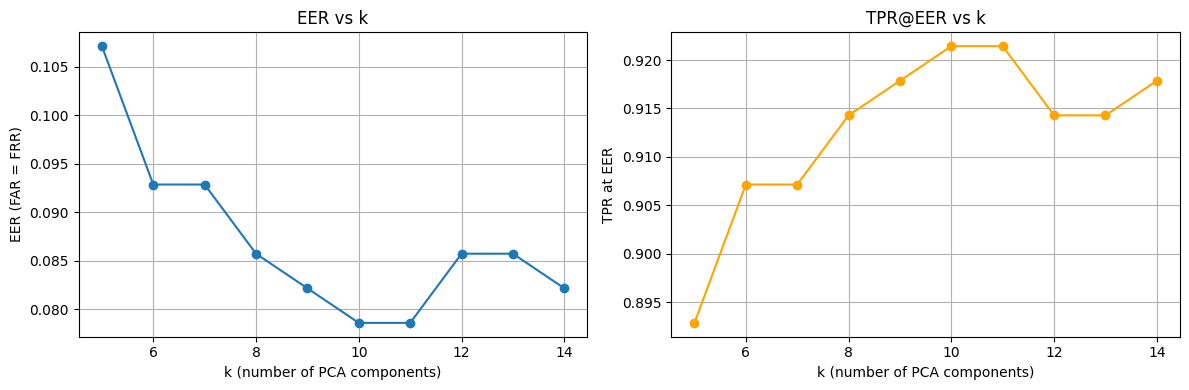

In [51]:
plt.figure(figsize=(12,4))

# ----- Graph 1: EER (error rate) -----
plt.subplot(1,2,1)
plt.plot(k_list, eer_results, marker='o')
plt.xlabel("k (number of PCA components)")
plt.ylabel("EER (FAR = FRR)")
plt.title("EER vs k")
plt.grid(True)

# ----- Graph 2: TPR at EER -----
plt.subplot(1,2,2)
plt.plot(k_list, eer_tpr_results, marker='o', color='orange')
plt.xlabel("k (number of PCA components)")
plt.ylabel("TPR at EER")
plt.title("TPR@EER vs k")
plt.grid(True)

plt.tight_layout()
plt.show()


    ANS: จากการทดลองพบว่าค่า EER ที่ดีที่สุด (TPR at EER สูงสุด, EER (FAR = FRR) ต่ำสุด) เกิดที่ k=10 และ k=11 ซึ่งให้ผลเท่ากัน อย่างไรก็ตามเลือก k=10 เป็นค่าที่ดีที่สุด เนื่องจากใช้จำนวนมิติน้อยกว่าแต่ให้ประสิทธิภาพเท่ากัน

### OT2. Reconstruct the first image using this procedure. Use k = 10, what is the MSE?

In [52]:
k = 10

x_original = T_vec[0] 
v_k = v[:, :k]
p = v_k.T @ (x_original - mean_vector)  
# reconstruction
x_recon = mean_vector + v_k @ p 
mse = np.mean((x_original - x_recon) ** 2)
print("MSE (k=10):", mse)

MSE (k=10): 0.006148335016488303


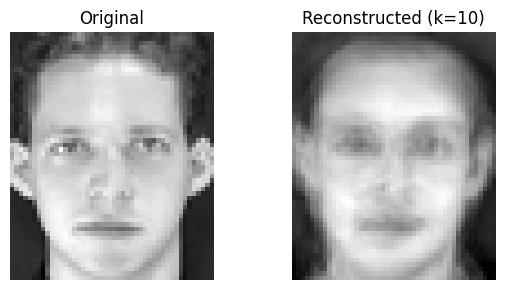

In [53]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(x_original.reshape(56,46), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(x_recon.reshape(56,46), cmap='gray')
plt.title("Reconstructed (k=10)")
plt.axis('off')

plt.tight_layout()
plt.show()

    ANS: MSE (k=10): 0.006148335016488303

### OT3. For k values of 1,2,3,...,10,119, show the reconstructed images. Plot the MSE values.

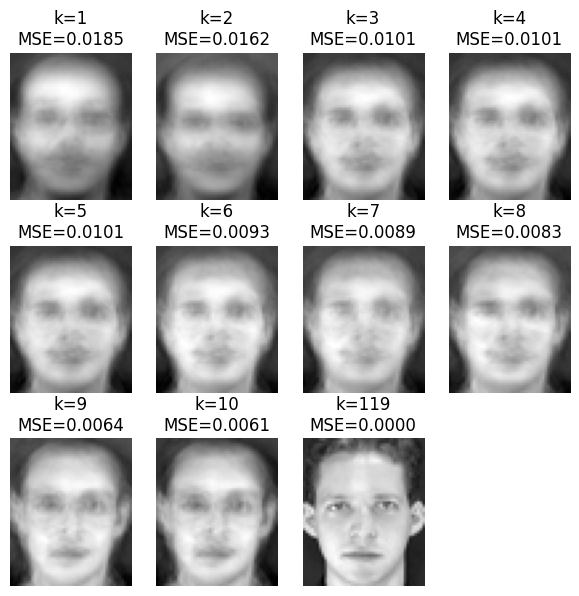

In [54]:
x_original = T_vec[0]          # (2576,)
meanface = mean_vector        # (2576,)

k_list = list(range(1, 11)) + [119]
mse_list = []

plt.figure(figsize=(6, 6))

for idx, k in enumerate(k_list):
    v_k = v[:, :k]             # (2576, k)

    # projection
    p = v_k.T @ (x_original - meanface)   # (k,)

    # reconstruction
    x_recon = meanface + v_k @ p           # (2576,)

    # MSE
    mse = np.mean((x_original - x_recon) ** 2)
    mse_list.append(mse)

    # plot
    plt.subplot(3, 4, idx + 1)
    plt.imshow(x_recon.reshape(56, 46), cmap='gray')
    plt.title(f"k={k}\nMSE={mse:.4f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


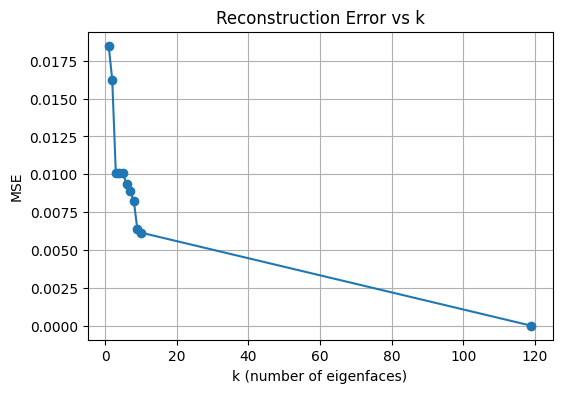

In [55]:
plt.figure(figsize=(6,4))
plt.plot(k_list, mse_list, marker='o')
plt.xlabel("k (number of eigenfaces)")
plt.ylabel("MSE")
plt.title("Reconstruction Error vs k")
plt.grid(True)
plt.show()

### OT4. Consider if we want to store 1,000,000 images of this type. How much space do we need? If we would like to compress the database by using the first 10 eigenvalues, how much space do we need? (Assume we keep the projection values, the eigenfaces, and the meanface as 32bit floats)

    ANS : 
    Info
        ขนาดภาพ: 56 × 46 = 2576 pixels 
        1 pixel เก็บเป็น 32-bit float = 4 bytes 
        จำนวนภาพ: 1,000,000 images
    เก็บภาพดิบ 1M images
        ขนาดต่อ 1 image : 2576 pixels × 4 bytes= 10,304 bytes ≈ 10.3 KB
        1M images : 10,304×1,000,000=10.304×10 9 bytes ≈ 10.3 GB 
    Compress ด้วย PCA (ใช้ k = 10 eigenfaces)
        Projection values 10 value : 1,000,000×10×4 = 40,000,000 bytes ≈ 40 MB
        Eigenfaces (เก็บครั้งเดียว) : 10×2576×4 = 103,040 bytes ≈ 0.10 MB
        Meanface (เก็บครั้งเดียว) : 2576×4 = 10,304 bytes ≈ 0.01 MB
        รวม 40 MB + 0.10 MB + 0.01 MB ≈ 40.1 MB
    ลดขนาดได้ประมาณ ≈ 256 เท่า


### T21. In order to assure that $S_W$ is invertible we need to make sure that $S_W$ is full rank. How many PCA dimensions do we need to keep in order for $S_W$ to be full rank? (Hint: How many dimensions does $S_W$ have? In order to be of full rank, you need to have the same number of linearly independent factors)

    ANS: Rank ของ Sw ขึ้บจำนวน Sample ของแต่ละ class กับจำนวน class rank(Sw_i​​) ≤ N_i−1
    Training class ต่อ 1 คน = 3 -> rank(Sw_i​​) ≤ 2
    รวมทั้งหมด rank(Sw​​) ≤ 40* 2 = 80
    ดังนั้นเพื่อ Sw full rank ต้องใช้ k ≤ 80 (เก็บ PCA dimensions ไม่เกิน 80 มิติ) 

In [56]:
# TODO: Define dimension of PCA.
n_dim = 80

# TODO: Find PCA of T and D with n_dim dimension.

### T22. Using the answer to the previous question, project the original in- put to the PCA subspace. Find the LDA projections. To find the inverse, use −1 numpy.linalg.inv. Is $S_W$ $S_B$ symmetric? Can we still use numpy.linalg.eigh? How many non-zero eigenvalues are there?


In [66]:
# TODO: Find the LDA projection.
v_k = v[:, :n_dim]

# Project training data to PCA space
T_pca = (T_vec - mean_vector) @ v_k

num_classes = 40
samples_per_class = 3

S_W = np.zeros((n_dim, n_dim))
S_B = np.zeros((n_dim, n_dim))

# global mean in PCA space
global_mean = np.mean(T_pca, axis=0)

for i in range(num_classes):
    class_samples = T_pca[i*samples_per_class:(i+1)*samples_per_class]
    class_mean = np.mean(class_samples, axis=0)

    # Within-class scatter
    for x in class_samples:
        diff = (x - class_mean).reshape(-1,1)
        S_W += diff @ diff.T

    # Between-class scatter
    mean_diff = (class_mean - global_mean).reshape(-1,1)
    S_B += mean_diff @ mean_diff.T

In [76]:
assert np.allclose(S_W, S_W.T)
assert np.allclose(S_B, S_B.T)

In [85]:
S_W_inv = np.linalg.inv(S_W)
M = S_W_inv @ S_B

eigenvalues, eigenvectors = np.linalg.eig(M)

# sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx].real
eigenvectors = eigenvectors[:, idx].real

In [86]:
# TODO: Find how many non-zero eigenvalues there are.
non_zero = np.sum(np.abs(eigenvalues) > 1e-6)
print("Number of non-zero eigenvalues:", non_zero)

Number of non-zero eigenvalues: 39


In [87]:
# เลือกเฉพาะ non-zero eigenvectors
non_zero_idx = np.where(np.abs(eigenvalues) > 1e-6)[0]
W_lda = eigenvectors[:, non_zero_idx]
# Project training data to LDA space
T_lda = T_pca @ W_lda

In [88]:
T_lda.shape

(120, 39)

    ANS: Sw และ SB เป็น symmetric matrix เนื่องจากสร้างจาก outer product ของเวกเตอร์ แต่ Sw_inv SB ไม่จำเป็นต้อง symmetric ดังนั้นจึงไม่สามารถใช้ numpy.linalg.eigh ได้ และต้องใช้ numpy.linalg.eig แทน
    และเนื่องจากมี 40 คลาส จำนวน eigenvalues ที่ไม่เป็นศูนย์จะมีได้ไม่เกิน 𝐶 − 1 = 39 และข้อนี้มี 39 ตัว


### T23. Plot the first 10 LDA eigenvectors as images (the 10 best projections). Note that in this setup, you need to convert back to the original image space by using the PCA projection. The LDA eigenvectors can be considered as a linear combination of eigenfaces. Compare the LDA projections with the PCA projections.

In [89]:
W_fisher = v_k @ W_lda
W_fisher = W_fisher / np.linalg.norm(W_fisher, axis=0, keepdims=True)

In [90]:
W_fisher.shape

(2576, 39)

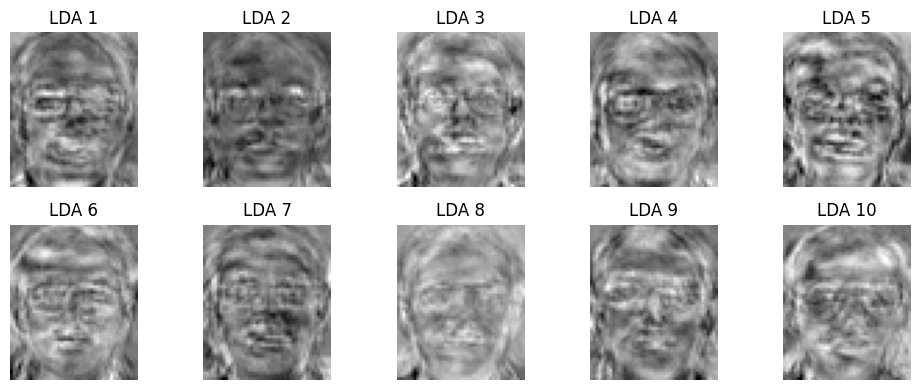

In [91]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    fisherface = W_fisher[:, i].reshape(56,46)
    plt.imshow(fisherface, cmap='gray')
    plt.title(f"LDA {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

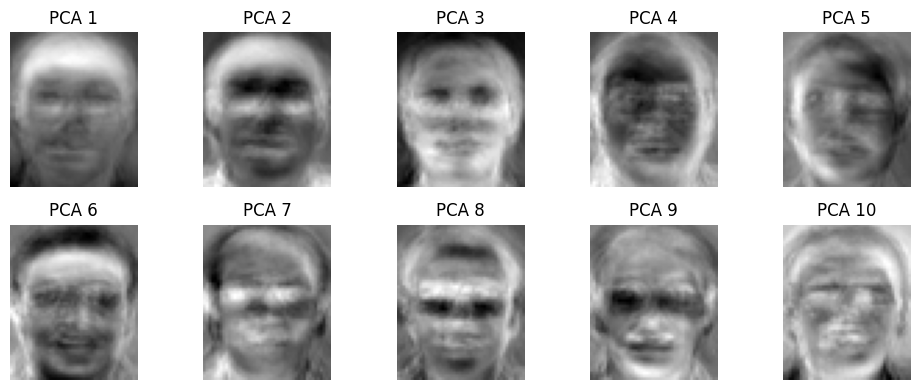

In [92]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    eigenface = v[:, i].reshape(56,46)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f"PCA {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### T24. The combined PCA+LDA projection procedure is called fisherface. Calculate the fisherfaces projection of all images. Do the simple face verification experiment using fisherfaces. What is the EER and recall rate at 0.1% FAR?

In [93]:
W_fisher = v_k @ W_lda
W_fisher = np.real(W_fisher)
# Project to fisherface space
T_fisher = (T_vec - mean_vector) @ W_fisher
D_fisher = (D_vec - mean_vector) @ W_fisher

In [94]:
T_fisher.shape, D_fisher.shape

((120, 39), (280, 39))

In [95]:
similarity_matrix_fisher = generate_similarity_matrix(T_fisher, D_fisher)

In [98]:
eer_tpr_fisher, recall_at_001_fisher, tpr_list_fisher, far_list_fisher = calculate_roc_metrics(similarity_matrix_fisher)

In [100]:
print("EER (FAR = FRR, Fisherfaces):", 1 - eer_tpr_fisher)
print("TPR at EER (Fisherfaces):", eer_tpr_fisher)
print("Recall at 0.1% FAR (Fisherfaces):", recall_at_001_fisher)

EER (FAR = FRR, Fisherfaces): 0.0714285714285714
TPR at EER (Fisherfaces): 0.9285714285714286
Recall at 0.1% FAR (Fisherfaces): 0.6785714285714286


    ANS: เมื่อใช้ Fisherface (PCA+LDA) พบว่าค่า EER ดีขึ้น (TPR ที่จุด EER เพิ่มจาก 92.14 -> 92.86, EER (error rate) ลดจาก 0.0786 -> 0.0714) เมื่อเทียบกับการใช้ PCA เพียงอย่างเดียว แสดงให้เห็นว่าการใช้ข้อมูลคลาสผ่าน LDA ช่วยเพิ่มความสามารถในการแยกแยะบุคคล นอกจากนี้ ค่า recall ที่ 0.1% FAR ยังสูงขึ้น (51 -> 67.8)  แสดงให้เห็นว่าระบบสามารถรักษาความแม่นยำได้ดีแม้กำหนด false alarm rate ต่ำ


### T25.Plot the RoC of all three experiments (No projection, PCA, andFisher) on the same axes. Compare and contrast the three results. Submit yourwriteup and code on MyCourseVille.

In [102]:
tpr_raw, far_raw = calculate_roc(similarity_matrix)
tpr_pca, far_pca = calculate_roc(similarity_matrix_pca)
tpr_fisher, far_fisher = calculate_roc(similarity_matrix_fisher)

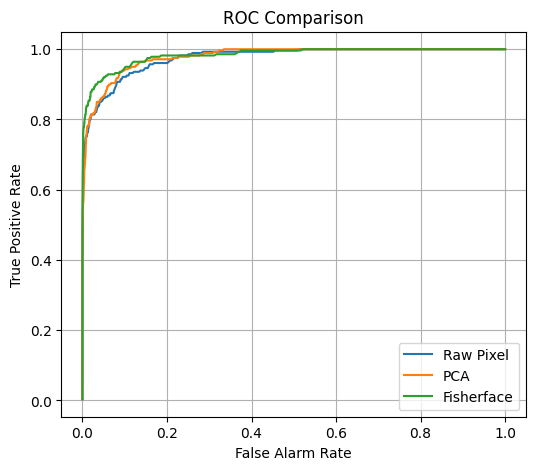

In [103]:
plt.figure(figsize=(6,5))

plt.plot(far_raw, tpr_raw, label="Raw Pixel")
plt.plot(far_pca, tpr_pca, label="PCA")
plt.plot(far_fisher, tpr_fisher, label="Fisherface")

plt.xlabel("False Alarm Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.grid(True)

plt.show()

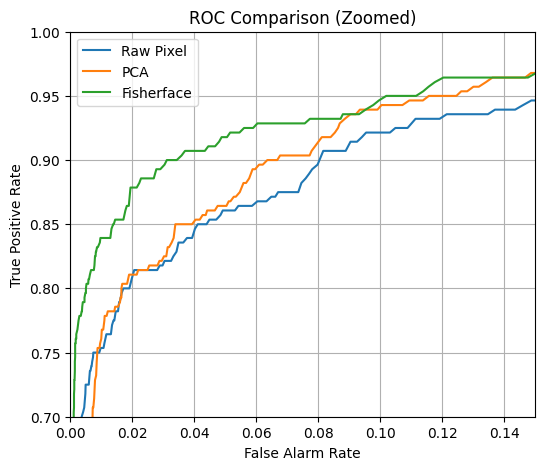

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(far_raw, tpr_raw, label="Raw Pixel")
plt.plot(far_pca, tpr_pca, label="PCA")
plt.plot(far_fisher, tpr_fisher, label="Fisherface")

plt.xlim(0, 0.15)      # zoom FAR ช่วงต่ำ
plt.ylim(0.7, 1.0)     # zoom TPR ช่วงบน

plt.xlabel("False Alarm Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (Zoomed)")
plt.legend()
plt.grid(True)

plt.show()

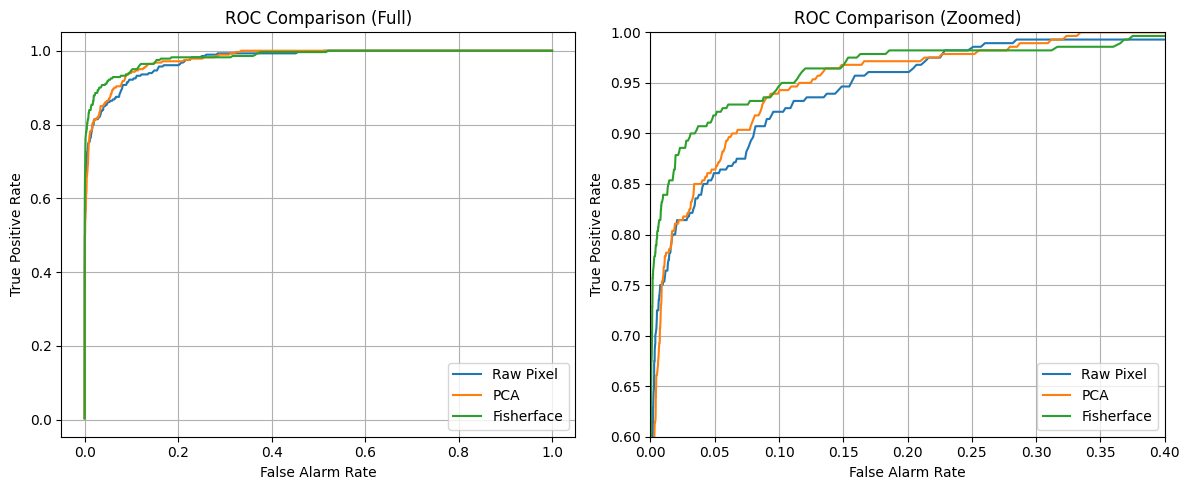

In [106]:
plt.figure(figsize=(12,5))

# ----------------------
# (1) Full ROC
# ----------------------
plt.subplot(1,2,1)
plt.plot(far_raw, tpr_raw, label="Raw Pixel")
plt.plot(far_pca, tpr_pca, label="PCA")
plt.plot(far_fisher, tpr_fisher, label="Fisherface")

plt.xlabel("False Alarm Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (Full)")
plt.legend()
plt.grid(True)


# ----------------------
# (2) Zoomed ROC
# ----------------------
plt.subplot(1,2,2)
plt.plot(far_raw, tpr_raw, label="Raw Pixel")
plt.plot(far_pca, tpr_pca, label="PCA")
plt.plot(far_fisher, tpr_fisher, label="Fisherface")

plt.xlim(0, 0.4)      # ซูมช่วง FAR ต่ำ
plt.ylim(0.6, 1.0)    # ซูมช่วง TPR บน

plt.xlabel("False Alarm Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (Zoomed)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

    ANS: จากกราฟ ROC จะเห็นว่า Fisherface ให้ผลลัพธ์ดีที่สุด โดยมีค่า TPR สูงกว่าวิธีอื่นในช่วง false alarm rate ต่ำ แสดงให้เห็นว่าการรวม PCA และ LDA ช่วยเพิ่มความสามารถในการแยกแยะบุคคลได้อย่างมีประสิทธิภาพ ในขณะที่ PCA ให้ผลดีกว่าการใช้ pixel ดิบ เนื่องจากช่วยลด noise และลดมิติของข้อมูล อย่างไรก็ตาม Fisherface ซึ่งใช้ข้อมูลคลาสผ่าน LDA สามารถเพิ่ม discriminative power ได้มากที่สุด

### OT5. Plot the first two LDA dimensions of the test images from different people (6 people 7 images each). Use a different color for each person. Observe the clustering of between each person. Repeat the same steps for the PCA projections. Does it come out as expected?

In [107]:
num_people = 6
num_test_images = 7

# D_vec คือ test images (flatten แล้ว)
# test images ถูกจัดเรียงเป็น 7 ภาพต่อคน

D_subset = []

for i in range(num_people):
    start = i * 7
    end = start + 7
    D_subset.append(D_vec[start:end])

D_subset = np.vstack(D_subset)

In [ ]:
k = 2
v_pca2 = v[:, :k]
D_pca2 = calculate_projection_vectors(D_subset, mean_vector, v_pca2)

In [ ]:
W_lda2 = W_fisher[:, :2]
D_lda2 = calculate_projection_vectors(D_subset, mean_vector, W_lda2)

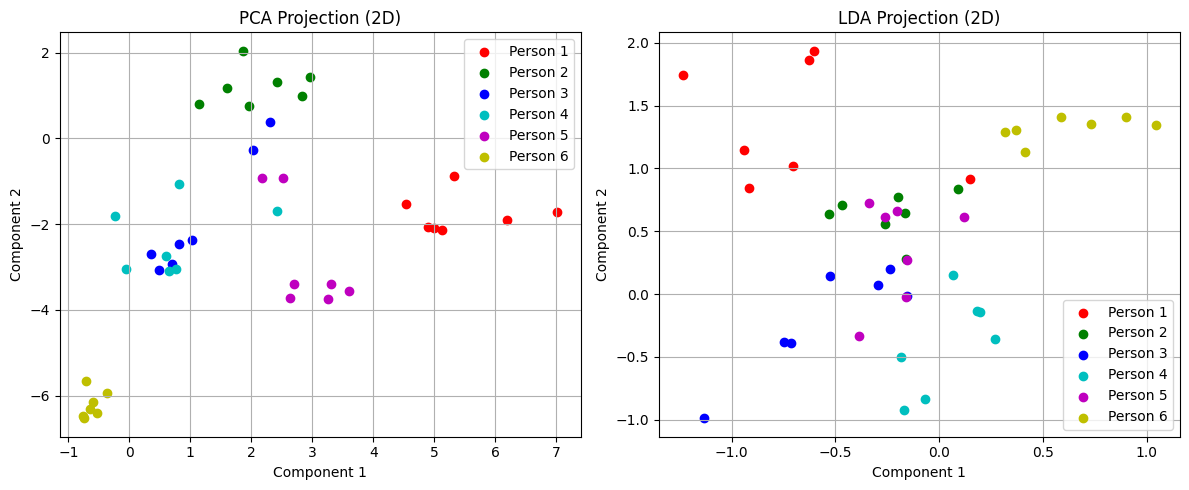

In [112]:
plt.figure(figsize=(12,5))

colors = ['r','g','b','c','m','y']

# ----------------------
# (1) PCA Projection
# ----------------------
plt.subplot(1,2,1)

for i in range(num_people):
    start = i * 7
    end = start + 7
    plt.scatter(D_pca2[start:end,0],
                D_pca2[start:end,1],
                color=colors[i],
                label=f'Person {i+1}')

plt.title("PCA Projection (2D)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.legend()


# ----------------------
# (2) LDA Projection
# ----------------------
plt.subplot(1,2,2)

for i in range(num_people):
    start = i * 7
    end = start + 7
    plt.scatter(D_lda2[start:end,0],
                D_lda2[start:end,1],
                color=colors[i],
                label=f'Person {i+1}')

plt.title("LDA Projection (2D)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

    ANS: จากกราฟจะเห็นว่า PCA สามารถจัดกลุ่มข้อมูลได้ระดับหนึ่ง แต่ยังมีการ overlap ระหว่างบางบุคคลอยู่ ในขณะที่ LDA ให้การแยกกลุ่มที่ชัดเจนกว่า แต่ละบุคคลมีการกระจายตัวเป็น cluster ที่แยกจากกันมากขึ้น ซึ่งเป็นไปตามทฤษฎี เพราะ PCA เน้นรักษา variance ของข้อมูล ส่วน LDA เน้นเพิ่มความสามารถในการแยกคลาสโดยตรง